# Documentation

## Module

Python 3.8 and FFmpeg are required for executing code from this module. Keep in mind that all quantities present in this program are specified in atomic units. This includes not only output such as the expectation values which are written to a file, but also input such as the grid dimensions and the time increment.

In [1]:
import wave_packet_dynamics as wpd

## Grid

The module provides a `Grid` class with helpful methods used by all other classes of the module. This is why one should start by creating a `Grid` object.

In [2]:
# create a 1 dimensional grid with bounds x_min and x_max
# the grid contains a finite number of points with even spacing
x_min = -3
x_max = 3
bounds = (x_min, x_max)
points = 3001
grid = wpd.Grid(bounds, points)

## Wave Functions and Potentials

The quantum dynamics simulation requires a wave function and a potential. For this the module provides the classes `WaveFunction` and `Potential`. When creating an instance of these classes, two  parameters  are  required:  a `Grid` object  and a function with only one parameter, the grid coordinate. Upon  initialisation, the provided function will then act on the `Grid` coordinates, resulting in an array containing discretized function values. These are labeled as the instance attribute `values`.

You can create your own wave and potential functions or use the predefined functions in the `wave_function` and `potential` submodules.  These functions require multiple parameters. However, the `WaveFunction` and `Potential` classes expect a function with only one parameter, the grid coordinate. `partial` from the `functools` module allows us to manipulate the given functions so that they only require this one parameter.

In [3]:
from wave_packet_dynamics import wave_function as wave
from wave_packet_dynamics import potential as pot

from functools import partial

# create a gaussian wave function with width 0.25 at initial x coordinate 1
# the particle has no initial momentum, meaning its initial wavenumber is 0
gaussian_function = partial(wave.gaussian, sigma=0.25, x0=1, k0=0)
wave_function = wpd.WaveFunction(grid, gaussian_function)

# create a parabola potential with force constant 10^2 centered at x coordinate 0
harmonic_function = partial(pot.harmonic, k=1*10**2, x0=0)
potential = wpd.Potential(grid, harmonic_function)

## Simulation and Animation

The `Simulation` class is the key component of this package. Creating an instance of this class by providing a `Grid`, `WaveFunction` and `Potential` object alongside a desired `time_increment` in atomic units primes the simulation. The simulation is executed by calling the instance and providing the run time in form of an integer `total_time_steps`.  A unique folder will be created in the working directory when executing the simulation, which will contain all associated files. The wave function will then evolve through time. Specifying additional keyword arguments when calling the simulation changes what data will be shown, how it will be represented in the animation and what data will be written to files.

Starting simulation:
Writing data from time step 1000 to file
Adding data from time step 1000 to animation
Deleting animation!
Simulation finished!


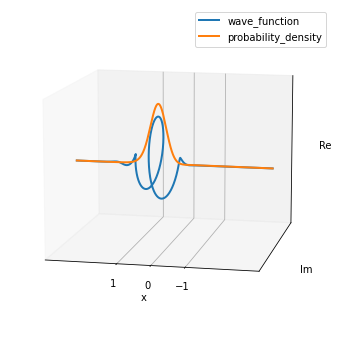

In [4]:
# create a simulation object
# provide a grid, wave function, potential and the time increment
# an optional name for the simulation can be added
dt = 2*10**-3
simulation = wpd.Simulation(grid, wave_function, potential, dt, "documentation")

# start the simulation by calling the instance
# provide the total number of time steps and optional keyword arguments
# -> take a look at the other examples for possible options
tn = 1000
simulation(tn, animate_step=tn,
           data_to_animate=["wave_function", "probability_density"],
           y_limits=(-2, 2), z_limits=(-2, 2), x_ticks=[-1, 0, 1],
           write_step=tn, data_to_write=["wave_function"],
           value_to_write=["integrated_density"])

# videos consisting only of 1 frame or less are deleted
# however the last frame of the animation is shown in jupyter notebook
# only the specified data and expectation values of the last timestep
# are written to a file by default

## Possible Keyword Arguments

... when calling a `Simulation` object.

- `animate_step`: `int`, default = `total_time_steps` − How often a simulation time step is animated, has to be a non-zero integer. Each animated time step is a frame of the animation.
- `data_to_animate`: `List[str]`,  default = `[]` −  List of data objects, which should be plotted at each animation frame, possible options are `"wave_function"`, `"probability_density"`, `"potential"`.
- `write_step`: `int`, default = `total_time_steps` − How often the data and expectation values are written to a file, has to be a non-zero integer.
- `data_to_write`: `List[str]`, default = `[]` − List of data objects, which should be written to a file at each `write_step`. Each new line of the corresponding file consists of the data from the next `write step`.  Depending on the number of grid points, these files get quite large pretty quick! Possible options are `"wave_function"`, `"probability_density"`, `"potential"`.
- `value_to_write`: `List[str]`, default = `[]` − List of expectation values which should be written to a file at each `write_step`. Each new line of the corresponding file consists of the expectation  value  from  the  next  write  step. Possible  options are `"integrated_density"`, `"position"`, `"momentum"`, `"potential_energy"`, `"kinetic_energy"`, `"total_energy"`.
- `x_limits`, `y_limits`, `z_limits`: `Tuple[float]` − Dimensions of the plotted area, defaults to the grid bounds for x limits and `(-1, 1)` for y and z limits.
- `xticks`, `y_ticks`, `z_ticks`: `List[float]`, default = `None` − List of ticks which should be shown on the axes in the animation.
- `fps`: `int`, default = `20` − Frames per second of the animation.
- `dpi`: `int`, default = `200` − Resolution of the animation in dots-per-inch. For reference, the canvas size is 9 by 4.5 inches.
- `bitrate`: `int`, default = `2500` − Bit rate of the animation, in kilobits per second.